# 03 Hybrid (self-sufficient end-to-end)

Trains **OC-SVM + autoencoder + fusion** from **`cic_ids_data` only** (Colab `MyDrive/cic_ids_data` or local `./cic_ids_data`). **No** other notebooks and **no** project `src` imports (`src/__init__.py`, `ids_pipeline.py`, `flow_autoencoder.py`); models and preprocessing are defined **in this file**. Artifacts: **`./artifacts/`** locally or `/content/artifacts/` on Colab.


In [5]:
# --- Inline CIC helpers: standalone — do not import src.ids_pipeline, src.flow_autoencoder, or src.__init__ ---
from __future__ import annotations

import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm


CIC_DAY_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]


@dataclass
class PreprocessArtifacts:
    features: List[str]
    dropped_corr_cols: List[str]
    benign_train_indices: List[int]
    benign_val_indices: List[int]
    feature_impute_medians: List[float]


def _impute_features_to_float32(
    df: pd.DataFrame, features: List[str], medians: np.ndarray
) -> np.ndarray:
    x = (
        df.reindex(columns=features)
        .replace([np.inf, -np.inf], np.nan)
        .to_numpy(dtype=np.float64)
    )
    med = np.asarray(medians, dtype=np.float64)
    med = np.where(np.isfinite(med), med, 0.0)
    nan_m = np.isnan(x)
    if nan_m.any():
        x = x.copy()
        x[nan_m] = np.broadcast_to(med, x.shape)[nan_m]
    np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return x.astype(np.float32, copy=False)


def norm_family(label: str) -> str:
    s = str(label).strip().replace("\x00", "")
    low = s.lower()
    if low == "benign":
        return "Benign"
    if "heartbleed" in low:
        return "Heartbleed"
    if "web attack" in low or "webattack" in low:
        return "WebAttack"
    if "portscan" in low:
        return "PortScan"
    if "dos" in low and "ddos" not in low:
        return "DoS"
    if "ddos" in low:
        return "DDoS"
    if "bot" in low:
        return "Bot"
    if "infiltration" in low:
        return "Infiltration"
    return s


def cic_report_row_name(raw_label: str) -> str:
    s = str(raw_label).strip()
    low = s.lower().replace("_", " ")
    if low == "benign":
        return "Benign (Validation)"
    if "ftp" in low and "patator" in low:
        return "FTP Bruteforce"
    if "ssh" in low and "patator" in low:
        return "SSH Bruteforce"
    if "slowloris" in low:
        return "DoS (Slowloris)"
    if "goldeneye" in low:
        return "DoS (GoldenEye)"
    if "hulk" in low:
        return "DoS (Hulk)"
    if "slowhttptest" in low or "slowhttps" in low:
        return "DoS (Slowhttps)"
    if "ddos" in low:
        return "DDoS"
    if "dos" in low and "ddos" not in low:
        return "DoS (other)"
    if "heartbleed" in low:
        return "Heartbleed"
    if "web" in low and ("bf" in low or "brute" in low):
        return "Web BF"
    if "xss" in low:
        return "Web XSS"
    if "sql" in low:
        return "Web SQL"
    if "infiltration" in low:
        return "Infiltration"
    if "bot" in low:
        return "Botnet"
    if "portscan" in low:
        return "PortScan"
    return s


def load_cic_data(
    data_dir: str | Path,
    chunk_rows: int = 200_000,
    max_total_rows: int | None = 900_000,
    max_benign_fraction: float = 0.7,
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    data_dir = Path(data_dir)
    target_total = int(max_total_rows) if max_total_rows else None
    target_benign = None if target_total is None else int(target_total * max_benign_fraction)
    per_file_benign = (
        None if target_benign is None else int(np.ceil(target_benign / len(CIC_DAY_FILES)))
    )
    per_file_attack = (
        None
        if target_total is None
        else int(np.ceil((target_total - target_benign) / len(CIC_DAY_FILES)))
    )

    benign_parts: List[pd.DataFrame] = []
    attack_parts: List[pd.DataFrame] = []
    for file_name in tqdm(CIC_DAY_FILES, desc="CIC CSV files"):
        csv_path = data_dir / file_name
        kept_benign = 0
        kept_attack = 0
        for chunk in pd.read_csv(csv_path, low_memory=True, chunksize=chunk_rows):
            chunk.columns = [c.strip() for c in chunk.columns]
            raw = chunk["Label"].astype(str).str.strip()
            y = (raw.str.lower() != "benign").astype(np.int8)
            fam = raw.map(norm_family)
            x = chunk.drop(columns=["Label"], errors="ignore").select_dtypes(include=[np.number])
            if x.empty:
                continue
            x = x.replace([np.inf, -np.inf], np.nan).astype(np.float32, copy=False)
            x["y"] = y.values
            x["attack_family"] = fam.values
            x["cic_label"] = raw.values
            benign = x[x["y"] == 0]
            attack = x[x["y"] == 1]

            if per_file_benign is not None and len(benign):
                remaining = max(0, per_file_benign - kept_benign)
                if len(benign) > remaining:
                    benign = benign.iloc[rng.choice(len(benign), size=remaining, replace=False)]
            if per_file_attack is not None and len(attack):
                remaining = max(0, per_file_attack - kept_attack)
                if len(attack) > remaining:
                    attack = attack.iloc[rng.choice(len(attack), size=remaining, replace=False)]

            if len(benign):
                benign_parts.append(benign)
                kept_benign += len(benign)
            if len(attack):
                attack_parts.append(attack)
                kept_attack += len(attack)
            if per_file_benign is not None and per_file_attack is not None:
                if kept_benign >= per_file_benign and kept_attack >= per_file_attack:
                    break

    full = pd.concat([*benign_parts, *attack_parts], ignore_index=True)
    full = full.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return full


def drop_correlated_columns(df: pd.DataFrame, threshold: float = 0.9) -> tuple[pd.DataFrame, list[str]]:
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    dropped = [col for col in upper.columns if (upper[col] > threshold).any()]
    reduced = df.drop(columns=dropped)
    return reduced, dropped


def fit_preprocess_on_benign(
    df: pd.DataFrame,
    seed: int = 42,
    corr_threshold: float = 0.9,
    benign_train_size: float = 0.75,
) -> tuple[pd.DataFrame, pd.DataFrame, StandardScaler, PreprocessArtifacts]:
    feature_cols = [
        c
        for c in df.columns
        if c not in {"y", "attack_family", "cic_label", "report_name"}
    ]
    benign = df[df["y"] == 0].copy()
    benign = benign.dropna(axis=0)

    benign_train, benign_val = train_test_split(
        benign, train_size=benign_train_size, shuffle=True, random_state=seed
    )
    train_features = benign_train[feature_cols]
    train_features, dropped = drop_correlated_columns(train_features, threshold=corr_threshold)
    final_features = list(train_features.columns)
    median_vec = benign_train[final_features].median().to_numpy(dtype=np.float64)
    median_vec = np.where(np.isfinite(median_vec), median_vec, 0.0)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(
        _impute_features_to_float32(benign_train[final_features], final_features, median_vec)
    )
    x_val = scaler.transform(
        _impute_features_to_float32(benign_val[final_features], final_features, median_vec)
    )

    artifacts = PreprocessArtifacts(
        features=final_features,
        dropped_corr_cols=dropped,
        benign_train_indices=benign_train.index.tolist(),
        benign_val_indices=benign_val.index.tolist(),
        feature_impute_medians=median_vec.tolist(),
    )
    return pd.DataFrame(x_train, columns=final_features), pd.DataFrame(
        x_val, columns=final_features
    ), scaler, artifacts


def iter_zero_day_folds(df: pd.DataFrame) -> Iterable[tuple[str, pd.DataFrame]]:
    attacks = df[df["y"] == 1].copy()
    col = "report_name" if "report_name" in df.columns else "attack_family"
    for family in sorted(attacks[col].unique()):
        yield str(family), attacks[attacks[col] == family].copy()


def binary_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray | None = None) -> Dict[str, float]:
    y_true = np.asarray(y_true).ravel().astype(np.int8)
    y_pred = np.asarray(y_pred).ravel().astype(np.int8)
    negatives = np.sum(y_true == 0)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    fpr = float(fp / max(negatives, 1))
    specificity = float(tn / max(negatives, 1)) if negatives else 0.0
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_binary": float(f1_score(y_true, y_pred, zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "fallout_fpr": fpr,
        "specificity": specificity,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
    return out


def macro_f1_from_family_results(rows: Sequence[Dict[str, float]]) -> float:
    if not rows:
        return 0.0
    return float(np.mean([r["f1_macro"] for r in rows]))


def save_json(path: str | Path, payload: dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def save_run_config(path: str | Path, config: dict, preprocess: PreprocessArtifacts | None = None) -> None:
    payload = {"config": config}
    if preprocess is not None:
        payload["preprocess"] = asdict(preprocess)
    save_json(path, payload)


def robust_z(x: np.ndarray, ref: np.ndarray) -> np.ndarray:
    med = float(np.median(ref))
    mad = float(np.median(np.abs(ref - med))) + 1e-9
    return (np.asarray(x, dtype=np.float64) - med) / mad


def split_attack_families_for_calibration(
    df: pd.DataFrame,
    seed: int,
    calib_fraction: float = 0.5,
) -> Tuple[List[str], List[str]]:
    col = "report_name" if "report_name" in df.columns else "attack_family"
    families = sorted(df.loc[df["y"] == 1, col].unique().tolist())
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(families))
    n_calib = max(1, int(round(len(families) * calib_fraction)))
    calib_set = {families[i] for i in perm[:n_calib]}
    test_set = [f for f in families if f not in calib_set]
    calib_list = [f for f in families if f in calib_set]
    return calib_list, test_set

# --- Google Drive: dataset only (this notebook trains ML + DL + hybrid from CSVs) ---
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except ModuleNotFoundError:
    pass

import shutil

def resolve_cic_data_dir() -> Path:
    marker = Path("Monday-WorkingHours.pcap_ISCX.csv")
    drive_root = Path("/content/drive/MyDrive/cic_ids_data")
    local_cache = Path("/content/cic_ids_data_local_cache")

    def full_cic_set(root: Path) -> bool:
        return root.is_dir() and all((root / n).is_file() for n in CIC_DAY_FILES)

    # Colab: pandas read_csv over Drive FUSE often dies with errno 107 (transport endpoint). Copy once to VM disk.
    if Path("/content").is_dir() and full_cic_set(drive_root):
        local_cache.mkdir(parents=True, exist_ok=True)
        for name in tqdm(CIC_DAY_FILES, desc="Cache CIC CSVs to /content"):
            src, dst = drive_root / name, local_cache / name
            if not dst.is_file() or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst)
        print("Using VM-local CSV cache:", local_cache)
        return local_cache.resolve()

    if Path("/content").is_dir() and full_cic_set(local_cache):
        print("Using VM-local CSV cache:", local_cache)
        return local_cache.resolve()

    for base in (drive_root, Path.cwd() / "cic_ids_data", Path.cwd().parent / "cic_ids_data"):
        if base.is_dir() and (base / marker).is_file():
            return base.resolve()
    raise FileNotFoundError(
        "CICIDS CSVs not found. Colab: put the 8 flow CSVs in MyDrive/cic_ids_data. "
        "Local/Jupyter: put them in ./cic_ids_data next to this notebook."
    )


DATA_DIR = resolve_cic_data_dir()
ROOT_ARTIFACTS = Path("/content/artifacts") if Path("/content").is_dir() else (Path.cwd() / "artifacts")
ROOT_ARTIFACTS.mkdir(parents=True, exist_ok=True)
print("Resolved DATA_DIR:", DATA_DIR)
print("Artifacts root:", ROOT_ARTIFACTS.resolve())

import os
import pickle
import random
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

OUT_ART = ROOT_ARTIFACTS / "hybrid"
ROOT_ART = ROOT_ARTIFACTS
CHUNK_ROWS = 50_000
MAX_TOTAL_ROWS = 14_000
MAX_BENIGN_FRACTION = 0.65
CORR_THRESHOLD = 0.9
CALIB_FAMILY_FRACTION = 0.5
SVM_NU_VALUES = [0.2, 0.15, 0.1]
RUN_IFOREST = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision('high')
    except AttributeError:
        pass
    BATCH_SIZE = 2048
    INFER_CHUNK = 16384
    AE_INFER_CHUNK = 32768
else:
    BATCH_SIZE = 1024
    INFER_CHUNK = 8192
    AE_INFER_CHUNK = 8192
NUM_EPOCHS = 4
RANDOM_SEARCH_TRIALS = 2
PAPER_MSE_THRESHOLDS = (0.05, 0.1, 0.15)
AE_THR_QUANTILES = [0.90, 0.95]
FUSION_WEIGHT_SLICES = np.linspace(0.25, 0.75, 5)
FUSION_Q = [0.92]

OUT_ART.mkdir(parents=True, exist_ok=True)

_USE_THUNDER = False
_GPUOCSVM = None
if torch.cuda.is_available():
    try:
        from thundersvm import OneClassSvm as _GPUOCSVM
        _USE_THUNDER = _GPUOCSVM is not None
    except ImportError:
        _GPUOCSVM = None


def make_ocsvm(nu: float):
    if _USE_THUNDER and _GPUOCSVM is not None:
        return _GPUOCSVM(kernel='rbf', nu=nu)
    # sklearn RBF OC-SVM scales poorly; verbose surfaces libsvm progress so runs won’t look frozen.
    return OneClassSVM(kernel='rbf', nu=nu, cache_size=2048, tol=1e-3, verbose=False)

if _USE_THUNDER:
    OCSVM_FIT_MAX_SAMPLES = None
else:
    OCSVM_FIT_MAX_SAMPLES = 10_000

print('DEVICE=', DEVICE, 'DATA_DIR=', DATA_DIR)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
if OCSVM_FIT_MAX_SAMPLES:
    print(
        'OC-SVM sklearn: fitting on at most',
        OCSVM_FIT_MAX_SAMPLES,
        'benign rows (reduce further if still slow; pip install thundersvm + GPU for larger/no cap).',
        flush=True,
    )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cache CIC CSVs to /content:   0%|          | 0/8 [00:00<?, ?it/s]

Using VM-local CSV cache: /content/cic_ids_data_local_cache
Resolved DATA_DIR: /content/cic_ids_data_local_cache
Artifacts root: /content/artifacts
DEVICE= cuda DATA_DIR= /content/cic_ids_data_local_cache
GPU: Tesla T4
OC-SVM sklearn: fitting on at most 10000 benign rows (reduce further if still slow; pip install thundersvm + GPU for larger/no cap).


In [6]:
# --- Load & preprocess once ---
df = load_cic_data(
    DATA_DIR,
    chunk_rows=CHUNK_ROWS,
    max_total_rows=MAX_TOTAL_ROWS,
    max_benign_fraction=MAX_BENIGN_FRACTION,
    seed=SEED,
)
print('Rows loaded:', len(df), 'benign~', int((df['y'] == 0).sum()))
df['report_name'] = df['cic_label'].astype(str).map(cic_report_row_name)
x_b_train, x_b_val, scaler, prep = fit_preprocess_on_benign(
    df, seed=SEED, corr_threshold=CORR_THRESHOLD
)
features = prep.features
input_dim = len(features)
med = np.asarray(prep.feature_impute_medians, dtype=np.float64)
x_val_np = scaler.transform(
    _impute_features_to_float32(df.loc[prep.benign_val_indices, features], features, med)
)
y_val_benign = np.zeros(len(x_val_np), dtype=np.int8)

_xb_full = x_b_train.to_numpy(np.float32)
_fit_rng = np.random.default_rng(SEED)
if (not _USE_THUNDER) and OCSVM_FIT_MAX_SAMPLES is not None and len(_xb_full) > OCSVM_FIT_MAX_SAMPLES:
    _idx = _fit_rng.choice(len(_xb_full), size=OCSVM_FIT_MAX_SAMPLES, replace=False)
    _xb_ocsvm_fit = _xb_full[_idx]
    print('OC-SVM fit benign rows:', len(_xb_ocsvm_fit), '/', len(_xb_full))
else:
    _xb_ocsvm_fit = _xb_full

# --- Classical One-Class SVM ---
svm_rows = []
best_oc = {'nu': None, 'macro_f1': -1.0, 'results': None, 'model': None}
for nu in tqdm(SVM_NU_VALUES, desc='OC-SVM ν'):
    print('\n[OC-SVM] ν=', nu, 'fitting', len(_xb_ocsvm_fit), 'rows (libsvm may print progress below)…', flush=True)
    svm = make_ocsvm(nu)
    svm.fit(_xb_ocsvm_fit)
    family_results = []
    for family, atk_df in tqdm(list(iter_zero_day_folds(df)), desc=f'SVM fam ν={nu}', leave=False):
        x_attack = scaler.transform(_impute_features_to_float32(atk_df[features], features, med))
        x_eval = np.vstack([x_val_np, x_attack])
        y_true = np.concatenate([y_val_benign, np.ones(len(x_attack), dtype=np.int8)])
        score = -svm.decision_function(x_eval)
        y_pred = (score > 0).astype(np.int8)
        metrics = binary_metrics(y_true, y_pred, score)
        metrics['family'] = family
        family_results.append(metrics)
    sb = -svm.decision_function(x_val_np)
    benign_val_acc = float(np.mean((sb > 0).astype(np.int8) == 0))
    macro_f1 = macro_f1_from_family_results(family_results)
    svm_rows.append(
        {
            'nu': nu,
            'macro_f1': macro_f1,
            'per_family': family_results,
            'benign_val_accuracy': benign_val_acc,
        }
    )
    if macro_f1 > best_oc['macro_f1']:
        best_oc = {'nu': nu, 'macro_f1': macro_f1, 'results': family_results, 'model': svm}
svm_model = best_oc['model']

if RUN_IFOREST:
    iso = IsolationForest(
        random_state=SEED, n_estimators=300, contamination=0.1, n_jobs=-1
    )
    iso.fit(x_b_train.to_numpy(np.float32))

# --- Autoencoder (same logic as notebook 02) ---
X_tr = torch.tensor(x_b_train.to_numpy(np.float32), dtype=torch.float32)
X_va = torch.tensor(x_b_val.to_numpy(np.float32), dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(X_tr, X_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == 'cuda',
)


class AutoEncoder(nn.Module):
    def __init__(self, n_in: int, h1: int, h2: int, h3: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, h2),
            nn.ReLU(inplace=True),
            nn.Linear(h2, h3),
            nn.ReLU(inplace=True),
            nn.Linear(h3, h2),
            nn.ReLU(inplace=True),
            nn.Linear(h2, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, n_in),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


@torch.no_grad()
def recon_mse_per_sample(model: nn.Module, x: torch.Tensor) -> np.ndarray:
    model.eval()
    dev = next(model.parameters()).device
    x = x.to(dev, non_blocking=True)
    out = model(x)
    return torch.mean((out - x) ** 2, dim=1).detach().cpu().numpy()


def train_one_ae(dims: tuple[int, int, int], lr: float, weight_decay: float) -> tuple[AutoEncoder, float]:
    h1, h2, h3 = dims
    model = AutoEncoder(input_dim, h1, h2, h3).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    use_amp = DEVICE.type == 'cuda'
    scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)
    amp_ctx = torch.amp.autocast('cuda', dtype=torch.float16) if use_amp else nullcontext()
    best_val = float('inf')
    best_state = None
    for _epoch in tqdm(range(NUM_EPOCHS), desc='AE epochs', leave=False):
        model.train()
        for xb, xb_tgt in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            xb_tgt = xb_tgt.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp_ctx:
                recon = model(xb)
                loss = loss_fn(recon, xb_tgt)
            if use_amp:
                scaler_amp.scale(loss).backward()
                scaler_amp.step(opt)
                scaler_amp.update()
            else:
                loss.backward()
                opt.step()
        val_mse = float(np.mean(recon_mse_per_sample(model, X_va)))
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val


rng_rs = random.Random(SEED)
candidates = [
    (64, 32, 64),
    (48, 24, 48),
    (80, 40, 80),
    (96, 48, 96),
    (128, 48, 128),
    (72, 36, 72),
    (56, 28, 56),
    (100, 50, 100),
]
lrs = [1e-3, 5e-4]
wds = [1e-4, 1e-3]
arch_space = []
for _ in range(RANDOM_SEARCH_TRIALS):
    arch_space.append((rng_rs.choice(candidates), rng_rs.choice(lrs), rng_rs.choice(wds)))

trial_results = []
best_torch = None
best_meta = None
best_val_global = float('inf')
for dims, lr, wd in tqdm(arch_space, desc='AE search'):
    m, val = train_one_ae(dims, lr, wd)
    trial_results.append({'h': dims, 'lr': lr, 'wd': wd, 'val': val})
    if val < best_val_global:
        best_val_global = val
        best_torch = m
        best_meta = {'dims': dims, 'lr': lr, 'weight_decay': wd}

assert best_torch is not None and best_meta is not None
benign_val_mse = recon_mse_per_sample(best_torch, X_va)
quantiles = AE_THR_QUANTILES
thr_grid = list(PAPER_MSE_THRESHOLDS) + [float(np.quantile(benign_val_mse, q)) for q in quantiles]
thr_grid = sorted(set(round(t, 8) for t in thr_grid))
ae_net = best_torch
ae_net.eval()


@torch.no_grad()
def ae_mse_np(x_np: np.ndarray) -> np.ndarray:
    x_np = np.asarray(x_np, dtype=np.float32)
    parts = []
    for i in range(0, len(x_np), AE_INFER_CHUNK):
        sl = x_np[i : i + AE_INFER_CHUNK]
        xt = torch.from_numpy(sl).to(DEVICE, non_blocking=True)
        parts.append(recon_mse_per_sample(ae_net, xt))
    return np.concatenate(parts)


def eval_ae_thr(thr: float):
    rows = []
    for family, atk_df in tqdm(list(iter_zero_day_folds(df)), desc='AE thr fam', leave=False):
        x_attack = scaler.transform(_impute_features_to_float32(atk_df[features], features, med))
        x_eval = np.vstack([x_val_np, x_attack])
        y_true = np.concatenate([y_val_benign, np.ones(len(x_attack), dtype=np.int8)])
        score = ae_mse_np(x_eval)
        y_pred = (score > thr).astype(np.int8)
        m = binary_metrics(y_true, y_pred, score)
        m['family'] = family
        rows.append(m)
    return macro_f1_from_family_results(rows), rows


best_thr = thr_grid[0]
best_macro = -1.0
best_ae_rows = []
for thr in tqdm(thr_grid, desc='AE thresholds'):
    mf1, rows = eval_ae_thr(thr)
    if mf1 > best_macro:
        best_macro = mf1
        best_thr = thr
        best_ae_rows = rows
thr_ae = float(best_thr)
print('Best OC nu:', best_oc['nu'], '| AE thr:', thr_ae)

# --- Hybrid fusion (saved models not required) ---
y_val_b = y_val_benign
svm_val = -np.asarray(svm_model.decision_function(x_val_np), dtype=np.float64)
ae_val = ae_mse_np(x_val_np)


def svm_sklearn_predictions(x_np):
    pred = svm_model.predict(x_np)
    return (pred == -1).astype(np.int8), None


def row_for_fold(family: str, scorer):
    _cc = "report_name" if "report_name" in df.columns else "attack_family"
    atk_df = df[(df['y'] == 1) & (df[_cc] == family)]
    if atk_df.empty:
        return None
    x_attack = scaler.transform(_impute_features_to_float32(atk_df[features], features, med))
    x_ev = np.vstack([x_val_np, x_attack])
    yt = np.concatenate([y_val_b, np.ones(len(x_attack), dtype=np.int8)])
    y_hat, extra = scorer(x_ev)
    m = binary_metrics(yt, y_hat, extra)
    m['family'] = family
    return m


def aggregate_rows(rows: list):
    cols = ['accuracy', 'recall', 'precision', 'f1_binary', 'f1_macro', 'specificity', 'fallout_fpr', 'roc_auc']
    clean = [{k: float(r.get(k, np.nan)) for k in cols} for r in rows]
    return {f'mean_fold_{k}': float(np.nanmean([d[k] for d in clean])) for k in cols}


def score_families(families: list[str], scorer):
    return [r for fam in families if (r := row_for_fold(fam, scorer)) is not None]


calib_fams, test_fams = split_attack_families_for_calibration(
    df, seed=SEED, calib_fraction=CALIB_FAMILY_FRACTION
)
print('Calib families:', calib_fams)
print('Test families:', test_fams)

calib_best = {'macro_f1_calib': -1.0, 'weights': None, 'thr': None}
weight_candidates = [{'w_svm': float(w), 'w_ae': float(round(1.0 - w, 8))} for w in FUSION_WEIGHT_SLICES]
quantiles_h = FUSION_Q

for cand in tqdm(weight_candidates, desc='Fusion w_svm'):
    w_svm, w_ae = cand['w_svm'], cand['w_ae']
    fused_ben = (w_svm * robust_z(svm_val, svm_val)) + (w_ae * robust_z(ae_val, ae_val))
    fused_ben_flat = fused_ben.astype(np.float64)
    for qq in quantiles_h:
        fused_thr_try = float(np.quantile(fused_ben_flat, qq))

        def hybrid_scorer(x_ev, ws=w_svm, wa=w_ae, ft=fused_thr_try):
            s_v = -np.asarray(svm_model.decision_function(x_ev), dtype=np.float64)
            s_a = ae_mse_np(x_ev)
            z = (ws * robust_z(s_v, svm_val)) + (wa * robust_z(s_a, ae_val))
            return ((z > ft).astype(np.int8), z)

        rows_calib = score_families(calib_fams, hybrid_scorer)
        if not rows_calib:
            continue
        mf = macro_f1_from_family_results(rows_calib)
        if mf > calib_best['macro_f1_calib']:
            calib_best = {
                'macro_f1_calib': float(mf),
                'weights': {'w_svm': w_svm, 'w_ae': w_ae},
                'thr': fused_thr_try,
                'thr_quantile': float(qq),
            }

BW_SVM = calib_best['weights']['w_svm']
BW_AE = calib_best['weights']['w_ae']
FUSED_THR = float(calib_best['thr'])
print('Fusion calibration:', calib_best)


def hybrid_deploy_scorer(x_ev):
    s_v = -np.asarray(svm_model.decision_function(x_ev), dtype=np.float64)
    s_a = ae_mse_np(x_ev)
    z = (BW_SVM * robust_z(s_v, svm_val)) + (BW_AE * robust_z(s_a, ae_val))
    return ((z > FUSED_THR).astype(np.int8), z)


def ae_scorer(x_ev):
    mse_sc = ae_mse_np(x_ev)
    return (mse_sc > thr_ae).astype(np.int8), mse_sc


ml_tbl = score_families(test_fams, svm_sklearn_predictions)
dl_tbl = score_families(test_fams, ae_scorer)
hb_tbl = score_families(test_fams, hybrid_deploy_scorer)

summary = pd.DataFrame(
    [
        {'model': 'ML_only_OC_SVM', 'macro_f1': macro_f1_from_family_results(ml_tbl), **aggregate_rows(ml_tbl)},
        {'model': 'DL_only_AE', 'macro_f1': macro_f1_from_family_results(dl_tbl), **aggregate_rows(dl_tbl)},
        {'model': 'Hybrid_fusion', 'macro_f1': macro_f1_from_family_results(hb_tbl), **aggregate_rows(hb_tbl)},
    ]
)
summary.round(6).to_csv(OUT_ART / 'ablation_summary.csv', index=False)
summary.round(6).to_csv(ROOT_ART / 'ablation_summary.csv', index=False)
save_json(
    OUT_ART / 'hybrid_results.json',
    {
        'calibration_attack_families': calib_fams,
        'evaluation_attack_families': test_fams,
        'fusion_calibration': {**calib_best, 'deploy_thr': FUSED_THR, 'ae_threshold': thr_ae, 'oc_nu': best_oc['nu']},
        'ablation_preview': summary.to_dict(orient='records'),
    },
)
save_run_config(
    OUT_ART / 'run_config.json',
    {'seed': SEED, 'data_dir': str(DATA_DIR), 'corr_threshold': CORR_THRESHOLD, 'calib_frac': CALIB_FAMILY_FRACTION},
    prep,
)
summary.round(6)


CIC CSV files:   0%|          | 0/8 [00:00<?, ?it/s]

Rows loaded: 12818 benign~ 9104


OC-SVM ν:   0%|          | 0/3 [00:00<?, ?it/s]


[OC-SVM] ν= 0.2 fitting 6825 rows (libsvm may print progress below)…


SVM fam ν=0.2:   0%|          | 0/7 [00:00<?, ?it/s]

...

Best OC nu: 0.1 | AE thr: 1.70064199
Calib families: ['DoS (Slowloris)', 'FTP Bruteforce', 'Infiltration', 'Web BF']
Test families: ['Botnet', 'DDoS', 'PortScan']


Fusion w_svm:   0%|          | 0/5 [00:00<?, ?it/s]

Fusion calibration: {'macro_f1_calib': 0.557504580392457, 'weights': {'w_svm': 0.625, 'w_ae': 0.375}, 'thr': 6.837036620456427, 'thr_quantile': 0.92}


/tmp/ipykernel_6892/4228029963.py:249: RuntimeWarning: Mean of empty slice
  return {f'mean_fold_{k}': float(np.nanmean([d[k] for d in clean])) for k in cols}


,model,macro_f1,mean_fold_accuracy,mean_fold_recall,mean_fold_precision,mean_fold_f1_binary,mean_fold_f1_macro,mean_fold_specificity,mean_fold_fallout_fpr,mean_fold_roc_auc
0,ML_only_OC_SVM,0.573507,0.775162,0.270256,0.314645,0.281031,0.573507,0.911209,0.088791,NaN
1,DL_only_AE,0.586835,0.802862,0.257205,0.372064,0.288720,0.586835,0.949890,0.050110,0.595684
2,Hybrid_fusion,0.575413,0.781163,0.265905,0.321293,0.280608,0.575413,0.920000,0.080000,0.649236


### Table 2 export + SVM vs AE bar charts (coursework-style)

Below: **Table 2** (CSV) matches the OC-SVM ν sweep; **bar charts** compare per-class **accuracy** at two operating points (blue = OC-SVM, orange = AE). **Macro-F1** in `summary` / `ablation_summary.csv` is the mean of per-fold `f1_macro` from `binary_metrics` (teacher-requested headline metric).


,Class,ν=0.2,ν=0.15,ν=0.1
0,Benign (Validation),81.45,86.90,91.12
1,Botnet,66.69,70.39,73.55
2,DDoS,79.16,83.45,86.77
3,DoS (Slowloris),76.59,80.51,83.48
4,FTP Bruteforce,73.41,68.59,71.88
5,Infiltration,81.57,86.89,91.04
6,PortScan,64.79,68.98,72.23
7,Web BF,65.30,69.60,72.89


AE thr fam:   0%|          | 0/7 [00:00<?, ?it/s]

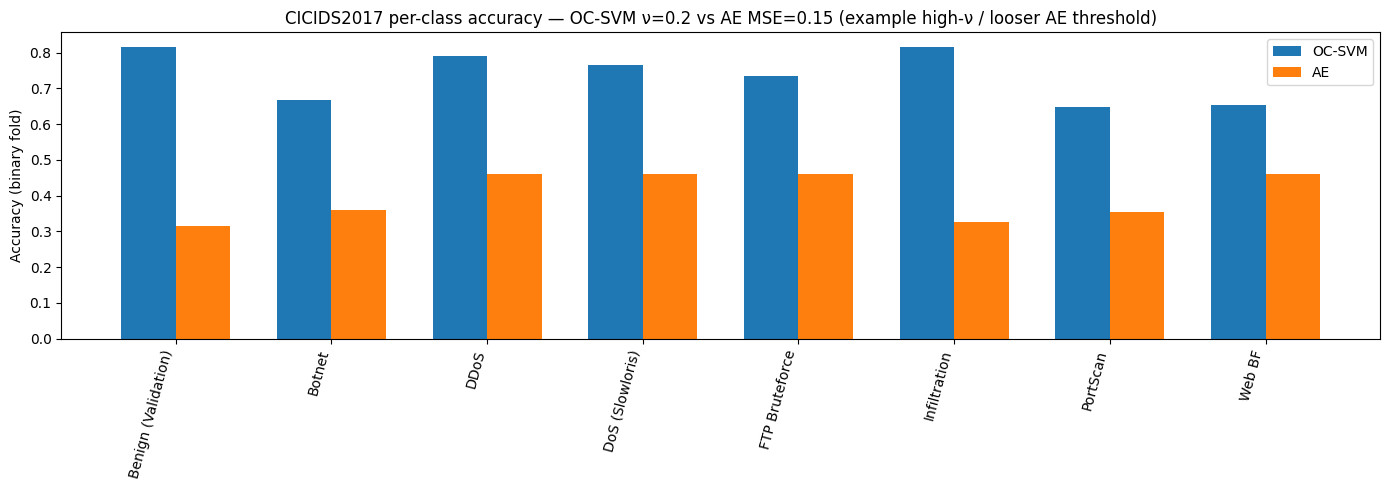

AE thr fam:   0%|          | 0/7 [00:00<?, ?it/s]

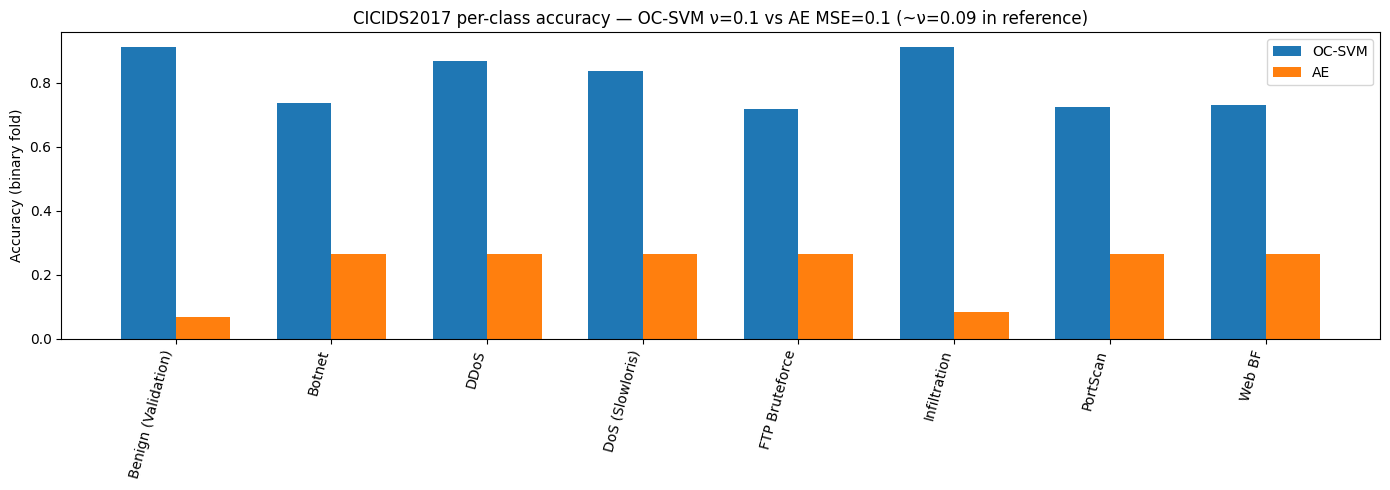

In [7]:
# --- Table 2 (CICIDS2017 OC-SVM): accuracy × ν + benign validation row ---
_figd = OUT_ART / "figures"
_figd.mkdir(parents=True, exist_ok=True)
_classes_t2 = ["Benign (Validation)"] + sorted(
    {m["family"] for row in svm_rows for m in row["per_family"]}
)
_rows_t2 = []
for cls in _classes_t2:
    rd = {"Class": cls}
    for row in svm_rows:
        nu = row["nu"]
        if cls == "Benign (Validation)":
            rd[f"ν={nu}"] = round(100.0 * row["benign_val_accuracy"], 2)
        else:
            fam = next((m for m in row["per_family"] if m["family"] == cls), None)
            rd[f"ν={nu}"] = round(100.0 * fam["accuracy"], 2) if fam else np.nan
    _rows_t2.append(rd)
table2_df = pd.DataFrame(_rows_t2)
table2_df.to_csv(_figd / "table2_svm_accuracy_cicids.csv", index=False)
display(table2_df)

# --- Bar charts: two operating points (ν=0.2 / AE thr 0.15) and (ν=0.1 / AE thr 0.1) ---


def _svm_acc_map(target_nu: float):
    row = next(r for r in svm_rows if abs(r["nu"] - target_nu) < 1e-9)
    out = {m["family"]: float(m["accuracy"]) for m in row["per_family"]}
    out["Benign (Validation)"] = float(row["benign_val_accuracy"])
    return out


def _ae_acc_map(thr: float):
    _, rws = eval_ae_thr(float(thr))
    out = {m["family"]: float(m["accuracy"]) for m in rws}
    sb = ae_mse_np(x_val_np)
    out["Benign (Validation)"] = float(np.mean(sb <= float(thr)))
    return out


def _order_classes(keys: set[str]):
    keys = set(keys)
    if "Benign (Validation)" in keys:
        keys.remove("Benign (Validation)")
        return ["Benign (Validation)"] + sorted(keys)
    return sorted(keys)

import matplotlib.pyplot as plt

for caption, nu_pt, thr_pt in [
    ("OC-SVM ν=0.2 vs AE MSE=0.15 (example high-ν / looser AE threshold)", 0.2, 0.15),
    ("OC-SVM ν=0.1 vs AE MSE=0.1 (~ν=0.09 in reference)", 0.1, 0.1),
]:
    svm_a = _svm_acc_map(nu_pt)
    ae_a = _ae_acc_map(thr_pt)
    cls_order = _order_classes(set(svm_a) | set(ae_a))
    x = np.arange(len(cls_order))
    w = 0.35
    plt.figure(figsize=(14, 5))
    plt.bar(
        x - w / 2,
        [svm_a[k] for k in cls_order],
        width=w,
        label="OC-SVM",
        color="#1f77b4",
    )
    plt.bar(
        x + w / 2,
        [ae_a.get(k, np.nan) for k in cls_order],
        width=w,
        label="AE",
        color="#ff7f0e",
    )
    plt.xticks(x, cls_order, rotation=75, ha="right")
    plt.ylabel("Accuracy (binary fold)")
    plt.title(f"CICIDS2017 per-class accuracy — {caption}")
    plt.legend()
    plt.tight_layout()
    fn = "svm_vs_ae_" + caption.split("(")[0].strip().replace(" ", "_").replace(".", "p")
    plt.savefig(_figd / f"{fn}.png", dpi=150)
    plt.show()


### Ablation (what breaks without ML, DL, or fusion)

Metrics below come from **`summary`** (held-out attack families after fusion weight calibration). **Macro-F1** is the primary score your instructor asked for; we report deltas vs hybrid.


In [8]:
ml = summary.loc[summary["model"] == "ML_only_OC_SVM", "macro_f1"].iloc[0]
dl = summary.loc[summary["model"] == "DL_only_AE", "macro_f1"].iloc[0]
hy = summary.loc[summary["model"] == "Hybrid_fusion", "macro_f1"].iloc[0]
print(
    "Macro-F1 — Hybrid:", round(hy, 4),
    "| ML-only:", round(ml, 4),
    "| DL-only:", round(dl, 4),
)
print(
    "Δ Macro-F1 vs hybrid — removing fusion (using ML only):",
    round(hy - ml, 4),
    "(hybrid improves when positive)",
)
print(
    "Δ Macro-F1 vs hybrid — removing fusion (using DL only):",
    round(hy - dl, 4),
)
print(
    "Gap ML vs DL (diagnostic):",
    round(ml - dl, 4),
)
# Narrative hook for the report: OC-SVM alone optimizes the kernel margin on benign; AE alone uses reconstruction error;
# hybrid combines robust-z scored OC-SVM + AE so neither single detector must carry all attack semantics.


Macro-F1 — Hybrid: 0.5754 | ML-only: 0.5735 | DL-only: 0.5868
Δ Macro-F1 vs hybrid — removing fusion (using ML only): 0.0019 (hybrid improves when positive)
Δ Macro-F1 vs hybrid — removing fusion (using DL only): -0.0114
Gap ML vs DL (diagnostic): -0.0133
